<div style="background-color: white; color: #2F1192; padding: 15px; border-radius: 5px; font-family: 'Times New Roman', Times, serif;">
    <h2 style="color: #2F1192; margin: 0; font-size:30px; "><b>Task 3: Heart Disease Prediction</b></h2>
</div>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, roc_auc_score,
                              roc_curve)
from sklearn.preprocessing import StandardScaler

In [4]:
df = pd.read_csv('heart.csv')
print(df.shape)
df.head()

(1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [5]:
# Check for missing values
print('Missing values:')
print(df.isnull().sum())
# Check target column distribution
print('Target distribution:')
print(df['target'].value_counts())
# 1 = has heart disease, 0 = no heart disease

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64
Target distribution:
target
1    526
0    499
Name: count, dtype: int64


In [12]:
sns.set_theme(
    style="whitegrid",
    rc={
        "axes.facecolor": "#f8f9fa",  # Soft, off-white background
        "grid.color": "#222222",      # Crisp black grid lines
        "grid.linewidth": 0.8,        # Clean, thin lines
    },
)

# 2. Define your custom colors
custom_colors = ["#AC96F3", "#2F1192", "#6A44E9"]

# Create a custom continuous colormap for the heatmap using your colors
custom_cmap = sns.blend_palette(custom_colors, as_cmap=True)

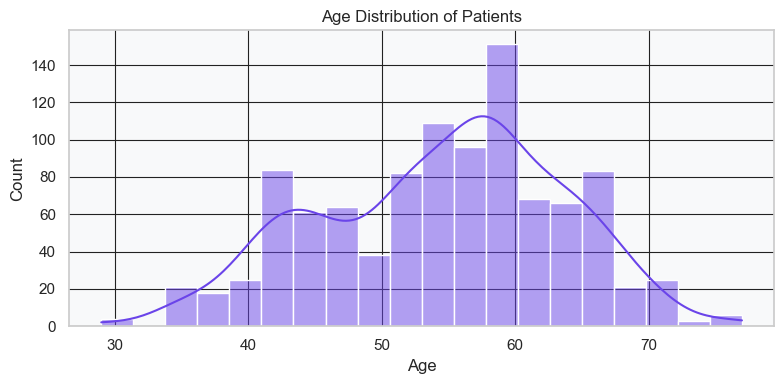

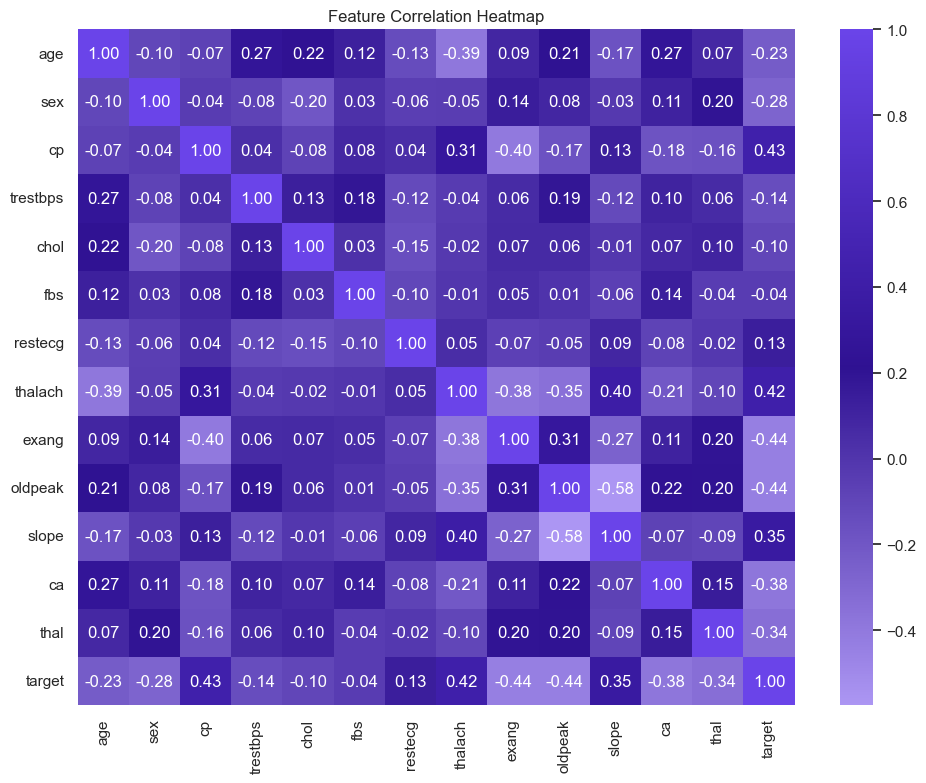

In [15]:
# Distribution of ages
plt.figure(figsize=(8,4))
sns.histplot(df['age'], bins=20, kde=True, color=custom_colors[2])
plt.title('Age Distribution of Patients')
plt.xlabel('Age'); plt.ylabel('Count')
plt.tight_layout(); plt.show()
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap=custom_cmap)
plt.title('Feature Correlation Heatmap')
plt.tight_layout(); plt.show()

In [16]:
X = df.drop('target', axis=1)   # all columns except target
y = df['target']                # what we want to predict
# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Scale features (important for Logistic Regression)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [17]:
# Train Logistic Regression
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)
# Make predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]  # probability scores
# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f'Accuracy: {acc*100:.2f}%')

Accuracy: 79.51%


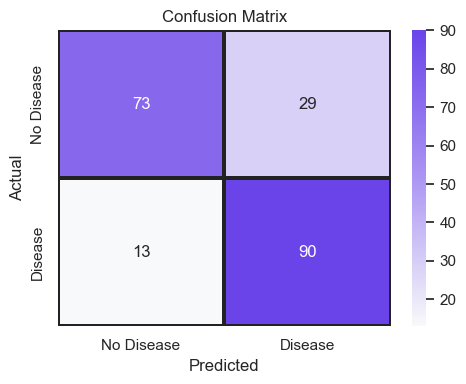

In [19]:
cm_cmap = sns.blend_palette(["#f8f9fa", custom_colors[0], custom_colors[2]], as_cmap=True)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap=cm_cmap,
            xticklabels=['No Disease','Disease'],
            yticklabels=['No Disease','Disease'],
            linewidths=1.5,             # Adds clean borders between cells
            linecolor="#222222",)
plt.title('Confusion Matrix')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()

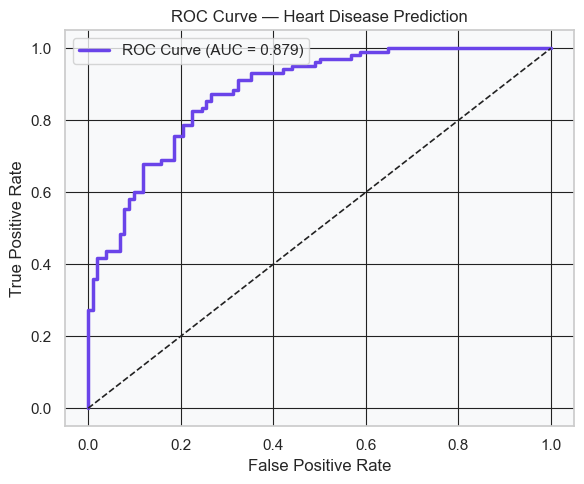

In [20]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color=custom_colors[2] , lw=2.5,
         label=f'ROC Curve (AUC = {auc:.3f})')
plt.plot([0,1],[0,1],color='#222222',linestyle='--',lw=1.2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Heart Disease Prediction')
plt.legend(); plt.tight_layout(); plt.show()


## Task 3: Summary of Findings

*   The dataset contains 14 features spanning patient demographics, medical metrics, and a target classification variable.
*   The target variable successfully categorizes patients into two distinct groups: **Disease** and **No Disease**.
*   The feature correlation heatmap indicates that chest pain (`cp`) and maximum heart rate achieved (`thalach`) have the strongest positive correlations with heart disease.
*   Features such as exercise-induced angina (`exang`), ST depression (`oldpeak`), and the number of major vessels (`ca`) show strong negative correlations with the target variable.
*   A Logistic Regression model trained on an 80/20 train-test split achieved an overall classification accuracy of **79.51%**.
*   The **Confusion Matrix** demonstrates strong predictive capabilities for identifying true risks, successfully predicting **90 true positive** cases of disease and **13 true negative** cases of no disease.
*   The model achieved a high **ROC-AUC score of 0.879**, confirming an excellent overall discriminative ability to separate patients with heart disease from those without it.